# 04. Дерево решений

## Модель

Дерево решений на табличных признаках. Ограничение `max_depth` (и при необходимости другие параметры) снижает переобучение и уменьшает глубокие ветвления. После обучения строятся **грубая схема дерева** и **матрица ошибок** на test.

In [ ]:
from pathlib import Path
import sys
import os

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "src" / "helpers.py").is_file():
        sys.path.insert(0, str((_p / "src").resolve()))
        os.chdir(_p)
        break

In [ ]:
from helpers import init_notebook_path, ensure_dirs, PROJECT_ROOT, PLOT_DIR, DATA_DIR, RANDOM_STATE
ROOT = init_notebook_path()
ensure_dirs()
print("PROJECT_ROOT", PROJECT_ROOT)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix
from helpers import (
    load_xy_from_processed,
    classification_metrics_dict,
    print_report,
    append_metrics_store,
    PLOT_DIR,
    CLASS_NAMES,
    feature_columns_default,
    RANDOM_STATE,
)

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test, feat_cols = load_xy_from_processed()

feature_names = list(feat_cols) if feat_cols is not None else list(feature_columns_default())

dt = DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Интерпретация

Решения — кусочно-постоянные границы по признакам; дерево **интерпретируемо** (можно проследить путь от корня к листу), в отличие от нейросетей.

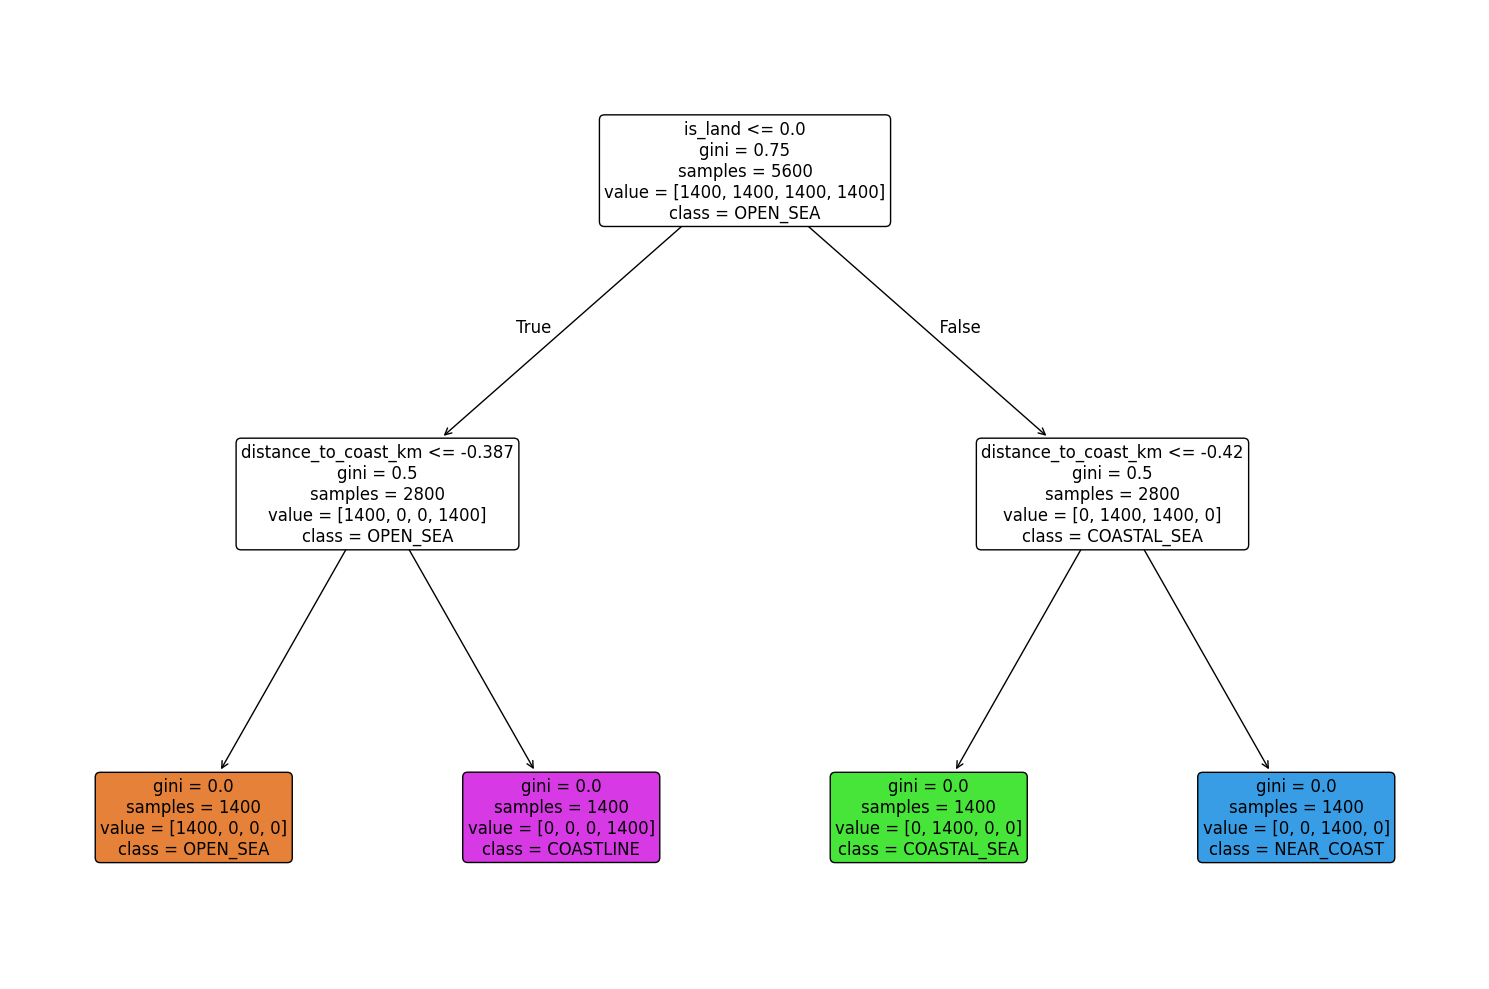

In [5]:
plt.figure(figsize=(15, 10))
plot_tree(
    dt,
    filled=True,
    feature_names=feature_names,
    class_names=list(map(str, CLASS_NAMES)),
    rounded=True,
)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'decision_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
y_pred = dt.predict(X_test)
m = classification_metrics_dict(y_test, y_pred)
print(m)
print_report(y_test, y_pred)

{'accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'f1_macro': 1.0, 'precision_micro': 1.0, 'recall_micro': 1.0, 'f1_micro': 1.0}
              precision    recall  f1-score   support

    OPEN_SEA       1.00      1.00      1.00       300
 COASTAL_SEA       1.00      1.00      1.00       300
  NEAR_COAST       1.00      1.00      1.00       300
   COASTLINE       1.00      1.00      1.00       300

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



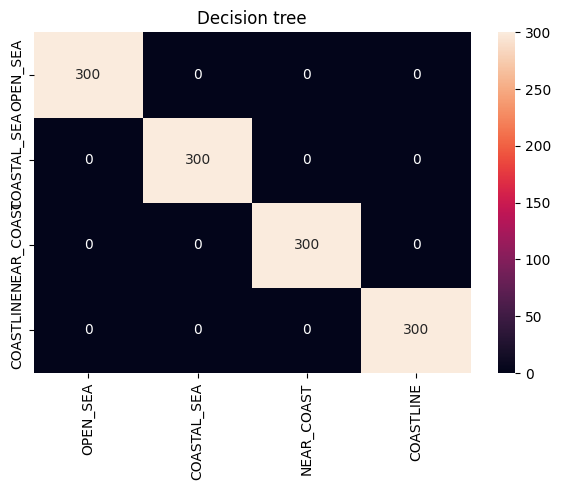

In [7]:
append_metrics_store('decision_tree', m)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Decision tree')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_tree.png', dpi=150)
plt.show()
plt.close()
